# 02 — CROHME Preprocessing

This notebook converts the CROHME InkML dataset into training-ready samples for handwritten mathematical expression recognition.

Pipeline:

1. Load the existing CROHME directory structure.
2. Parse InkML files using the project's existing `parse_inkml` function.
3. Normalize stroke coordinates.
4. Render each expression as a grayscale PNG while preserving aspect ratio.
5. Normalize and tokenize LaTeX.
6. Build the vocabulary from the training split only.
7. Convert target tokens to integer IDs.
8. Create JSONL manifests for train/valid/test.
9. Save metadata, vocabulary, failed-file information, and preprocessing statistics.
10. Visually validate the processed samples.

The source dataset is not modified.


In [ ]:
def display_path(path):
    return "/abhista/HMER" + str(path).split("/HMER", 1)[1]

In [2]:
from pathlib import Path
import sys
import json
import re
import math
from collections import Counter

import numpy as np
import pandas as pd  # type: ignore
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

# Keep the same project-root convention used in 01_crohme_exploration.ipynb.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.inkml_parser import parse_inkml


DATASET_ROOT = PROJECT_ROOT / "data" / "crohme2019"

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "crohme2019"

IMAGE_DIR = PROCESSED_ROOT / "images"
METADATA_DIR = PROCESSED_ROOT / "metadata"
MANIFEST_DIR = PROCESSED_ROOT / "manifests"

TRAIN_IMAGE_DIR = IMAGE_DIR / "train"
VALID_IMAGE_DIR = IMAGE_DIR / "valid"
TEST_IMAGE_DIR = IMAGE_DIR / "test"

for directory in [
    TRAIN_IMAGE_DIR,
    VALID_IMAGE_DIR,
    TEST_IMAGE_DIR,
    METADATA_DIR,
    MANIFEST_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {display_path(PROJECT_ROOT)}")
print(f"Dataset root:   {display_path(DATASET_ROOT)}")
print(f"Processed root: {display_path(PROCESSED_ROOT)}")


Project root: /abhista/HMER
Dataset root:   /abhista/HMER/data/crohme2019
Processed root: /abhista/HMER/data/processed/crohme2019


In [3]:
# Verify the exact directory structure expected by the previous notebook.

required_directories = {
    "dataset": DATASET_ROOT,
    "train": TRAIN_DIR,
    "valid": VALID_DIR,
    "test": TEST_DIR,
}

for name, path in required_directories.items():
    print(f"{name:8s}: {path} | exists={path.exists()}")

assert DATASET_ROOT.exists(), f"Dataset root not found: {DATASET_ROOT}"
assert TRAIN_DIR.exists(), f"Train directory not found: {TRAIN_DIR}"
assert VALID_DIR.exists(), f"Valid directory not found: {VALID_DIR}"
assert TEST_DIR.exists(), f"Test directory not found: {TEST_DIR}"

train_files = sorted(TRAIN_DIR.glob("*.inkml"))
valid_files = sorted(VALID_DIR.glob("*.inkml"))
test_files = sorted(TEST_DIR.glob("*.inkml"))

print()
print(f"Train: {len(train_files)}")
print(f"Valid: {len(valid_files)}")
print(f"Test:  {len(test_files)}")
print(f"Total: {len(train_files) + len(valid_files) + len(test_files)}")


dataset : /data1/students/abhista/HMER/data/crohme2019 | exists=True
train   : /data1/students/abhista/HMER/data/crohme2019/train | exists=True
valid   : /data1/students/abhista/HMER/data/crohme2019/valid | exists=True
test    : /data1/students/abhista/HMER/data/crohme2019/test | exists=True

Train: 8901
Valid: 986
Test:  1199
Total: 11086


## 1. Preprocessing configuration

The image renderer uses a fixed target height but computes the width from the expression's aspect ratio. A maximum width prevents pathological expressions from producing impractically large files.

The original stroke coordinates are retained in the metadata; the normalized coordinates are used only for rendering.


In [4]:
# Image rendering configuration.

IMAGE_HEIGHT = 128
MAX_IMAGE_WIDTH = 1024

# Padding around the normalized expression in pixels.
IMAGE_PADDING = 8

# Render at a larger resolution and downsample for smoother strokes.
RENDER_SCALE = 4

# Stroke width in the high-resolution rendering.
STROKE_WIDTH = 2 * RENDER_SCALE

# Background and ink values for grayscale images.
BACKGROUND_VALUE = 255
INK_VALUE = 0

# Minimum numerical span used to avoid division by zero.
EPSILON = 1e-8

print("Image height:       ", IMAGE_HEIGHT)
print("Maximum image width:", MAX_IMAGE_WIDTH)
print("Image padding:      ", IMAGE_PADDING)
print("Render scale:       ", RENDER_SCALE)


Image height:        128
Maximum image width: 1024
Image padding:       8
Render scale:        4


## 2. LaTeX normalization and tokenization

CROHME contains expressions with and without `$...$` delimiters. The delimiters are formatting markers rather than mathematical tokens, so they are removed.

The tokenizer treats:

- LaTeX commands such as `\frac`, `\sqrt`, `\alpha` as single tokens.
- Individual letters as individual tokens.
- Individual digits as individual tokens.
- Operators and punctuation as individual tokens.
- `{` and `}` as individual structural tokens.

The training vocabulary is built **only from the training split**.


In [5]:
LATEX_WHITESPACE_RE = re.compile(r"\s+")
LATEX_TOKEN_RE = re.compile(
    r"""
    \\[A-Za-z]+        # LaTeX command, e.g. \frac, \alpha, \mbox
    |\\[^A-Za-z\s]     # escaped single character, e.g. \{
    |[A-Za-z]          # individual letter
    |[0-9]             # individual digit
    |[{}]              # grouping
    |[()\[\]]          # delimiters
    |[+\-=*/.,:;!?]    # common operators/punctuation
    |[<>|]             # relation/set symbols
    |_                 # subscript
    |\^                # superscript
    |%                 # percent
    |&
    """,
    re.VERBOSE,
)


def normalize_latex(latex):
    """Normalize only formatting-level variation; do not alter mathematical meaning."""
    if latex is None:
        return ""

    latex = str(latex).strip()

    # Remove optional math-mode delimiters used in some CROHME labels.
    latex = latex.replace("$", "")

    # Normalize repeated whitespace.
    latex = LATEX_WHITESPACE_RE.sub(" ", latex).strip()

    return latex


def tokenize_latex(latex):
    """Convert normalized CROHME LaTeX into a deterministic token sequence."""
    normalized = normalize_latex(latex)

    if not normalized:
        return []

    tokens = LATEX_TOKEN_RE.findall(normalized)

    # Make sure tokenization did not silently discard unsupported characters.
    reconstructed = "".join(tokens)
    source_without_spaces = re.sub(r"\s+", "", normalized)

    if reconstructed != source_without_spaces:
        unsupported = sorted(set(source_without_spaces) - set(reconstructed))
        raise ValueError(
            f"Unsupported LaTeX content detected: {unsupported} | "
            f"expression={normalized!r}"
        )

    return tokens


# Quick tokenizer sanity checks.
examples = [
    r"$x^2 + y^2 = z^2$",
    r"\frac { a } { b }",
    r"\sqrt{x} + \alpha",
    r"{ \mbox { o } } ^ { { \beta + \mbox { r } } }",
]

for expression in examples:
    print(expression)
    print(tokenize_latex(expression))
    print()


$x^2 + y^2 = z^2$
['x', '^', '2', '+', 'y', '^', '2', '=', 'z', '^', '2']

\frac { a } { b }
['\\frac', '{', 'a', '}', '{', 'b', '}']

\sqrt{x} + \alpha
['\\sqrt', '{', 'x', '}', '+', '\\alpha']

{ \mbox { o } } ^ { { \beta + \mbox { r } } }
['{', '\\mbox', '{', 'o', '}', '}', '^', '{', '{', '\\beta', '+', '\\mbox', '{', 'r', '}', '}', '}']



## 3. Parse and normalize strokes

Each InkML file is parsed with the same `parse_inkml()` function used by the exploration notebook.

Normalization:

1. Convert coordinates to floating point.
2. Remove translation by shifting the minimum x/y to zero.
3. Scale the expression uniformly so that its largest dimension fits the target rendering area.
4. Preserve the original stroke boundaries and point order.


In [6]:
def clean_strokes(strokes):
    """Convert parser output into lists of finite (x, y) float pairs."""
    cleaned = []

    for stroke in strokes:
        points = []

        for point in stroke:
            if len(point) < 2:
                continue

            x = float(point[0])
            y = float(point[1])

            if not (math.isfinite(x) and math.isfinite(y)):
                continue

            points.append((x, y))

        if points:
            cleaned.append(points)

    return cleaned


def normalize_strokes(strokes):
    """Translation and uniform scale normalization while preserving stroke structure."""
    strokes = clean_strokes(strokes)

    if not strokes:
        return [], {
            "min_x": 0.0,
            "min_y": 0.0,
            "max_x": 0.0,
            "max_y": 0.0,
            "width": 0.0,
            "height": 0.0,
            "scale": 1.0,
        }

    all_points = np.asarray(
        [point for stroke in strokes for point in stroke],
        dtype=np.float64,
    )

    min_x = float(all_points[:, 0].min())
    max_x = float(all_points[:, 0].max())
    min_y = float(all_points[:, 1].min())
    max_y = float(all_points[:, 1].max())

    width = max_x - min_x
    height = max_y - min_y

    span = max(width, height)

    if span <= EPSILON:
        scale = 1.0
    else:
        target_span = max(1, IMAGE_HEIGHT - 2 * IMAGE_PADDING)
        scale = target_span / span

    normalized = []

    for stroke in strokes:
        normalized_stroke = [
            (
                (x - min_x) * scale,
                (y - min_y) * scale,
            )
            for x, y in stroke
        ]
        normalized.append(normalized_stroke)

    return normalized, {
        "min_x": min_x,
        "min_y": min_y,
        "max_x": max_x,
        "max_y": max_y,
        "width": width,
        "height": height,
        "scale": scale,
    }


## 4. Render normalized strokes to grayscale images

The output is a white-background, black-ink PNG.

The renderer preserves the expression's aspect ratio. It does not stretch a wide equation into a square image.


In [7]:
def render_strokes(strokes, image_height=IMAGE_HEIGHT, max_width=MAX_IMAGE_WIDTH):
    """Render normalized strokes to a grayscale PIL image."""
    if not strokes:
        raise ValueError("Cannot render an expression with no valid strokes.")

    all_points = [point for stroke in strokes for point in stroke]

    max_x = max(point[0] for point in all_points)
    max_y = max(point[1] for point in all_points)

    # The normalization targets the height. Add padding around the expression.
    content_width = max_x
    content_height = max_y

    target_content_height = max(1, image_height - 2 * IMAGE_PADDING)

    if content_height <= EPSILON:
        scale = 1.0
    else:
        scale = target_content_height / content_height

    width = int(math.ceil(content_width * scale)) + 2 * IMAGE_PADDING
    height = image_height

    width = max(width, 2 * IMAGE_PADDING + 1)
    width = min(width, max_width)

    # If the width is capped, scale both axes uniformly.
    if width < int(math.ceil(content_width * scale)) + 2 * IMAGE_PADDING:
        available_width = max(1, width - 2 * IMAGE_PADDING)
        if content_width > EPSILON:
            scale = available_width / content_width

    high_width = max(1, width * RENDER_SCALE)
    high_height = max(1, height * RENDER_SCALE)

    image = Image.new(
        "L",
        (high_width, high_height),
        color=BACKGROUND_VALUE,
    )

    draw = ImageDraw.Draw(image)

    for stroke in strokes:
        if len(stroke) == 1:
            x, y = stroke[0]
            px = int(round((x * scale + IMAGE_PADDING) * RENDER_SCALE))
            py = int(round((y * scale + IMAGE_PADDING) * RENDER_SCALE))
            r = max(1, STROKE_WIDTH // 2)
            draw.ellipse(
                (px - r, py - r, px + r, py + r),
                fill=INK_VALUE,
            )
            continue

        points = [
            (
                int(round((x * scale + IMAGE_PADDING) * RENDER_SCALE)),
                int(round((y * scale + IMAGE_PADDING) * RENDER_SCALE)),
            )
            for x, y in stroke
        ]

        draw.line(
            points,
            fill=INK_VALUE,
            width=STROKE_WIDTH,
            joint="curve",
        )

    # Downsample for smoother final strokes.
    image = image.resize(
        (width, height),
        Image.Resampling.LANCZOS,
    )

    return image


## 5. Parse a single sample

This cell combines parsing, stroke normalization, LaTeX normalization, tokenization, and image rendering.

The result is the core representation that will later be consumed by the PyTorch dataset.


ID:              101_Fabricio
File:            101_Fabricio.inkml
LaTeX:           S = \Bigg( \sum_{i=1}^{n} \theta_i - (n-2)\pi \Bigg)r^2
Tokens:          ['S', '=', '\\Bigg', '(', '\\sum', '_', '{', 'i', '=', '1', '}', '^', '{', 'n', '}', '\\theta', '_', 'i', '-', '(', 'n', '-', '2', ')', '\\pi', '\\Bigg', ')', 'r', '^', '2']
Number tokens:   30
Number strokes:  27
Image size:      622 x 128


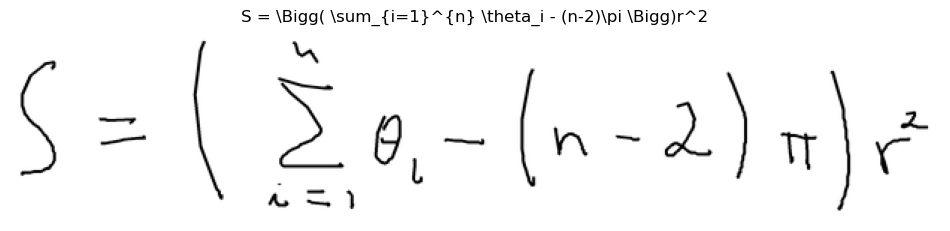

In [8]:
def process_sample(file_path, split):
    """Process one CROHME InkML file into a training-ready record."""
    result = parse_inkml(file_path)

    raw_strokes = result["strokes"]
    latex = result.get("latex") or ""

    normalized_latex = normalize_latex(latex)
    tokens = tokenize_latex(normalized_latex)

    if not normalized_latex:
        raise ValueError("Empty LaTeX target.")

    if not tokens:
        raise ValueError("LaTeX produced zero tokens.")

    normalized_strokes, geometry = normalize_strokes(raw_strokes)

    if not normalized_strokes:
        raise ValueError("No valid strokes.")

    image = render_strokes(normalized_strokes)

    sample_id = file_path.stem

    return {
        "id": sample_id,
        "split": split,
        "file": file_path.name,
        "source_path": str(file_path),
        "latex": normalized_latex,
        "tokens": tokens,
        "num_tokens": len(tokens),
        "num_strokes": len(normalized_strokes),
        "num_points": sum(len(stroke) for stroke in normalized_strokes),
        "original_width": geometry["width"],
        "original_height": geometry["height"],
        "original_aspect_ratio": (
            geometry["width"] / geometry["height"]
            if geometry["height"] > EPSILON
            else None
        ),
        "normalization_scale": geometry["scale"],
        "image_width": image.width,
        "image_height": image.height,
        "image": None,
        "_image_object": image,
    }


# Test one training sample before processing the entire dataset.
sample = process_sample(train_files[0], "train")

print("ID:             ", sample["id"])
print("File:           ", sample["file"])
print("LaTeX:          ", sample["latex"])
print("Tokens:         ", sample["tokens"])
print("Number tokens:  ", sample["num_tokens"])
print("Number strokes: ", sample["num_strokes"])
print("Image size:     ", sample["image_width"], "x", sample["image_height"])

plt.figure(figsize=(12, 3))
plt.imshow(sample["_image_object"], cmap="gray")
plt.axis("off")
plt.title(sample["latex"])
plt.show()


## 6. Process all splits

A failed file is recorded in `failed_files.json` and does not stop the preprocessing run.

This preserves the behavior observed in the exploration notebook, where `MfrDB0104.inkml` fails XML parsing.


In [9]:
def process_split(files, split, output_image_dir):
    records = []
    failures = []

    output_image_dir.mkdir(parents=True, exist_ok=True)

    for index, file_path in enumerate(files, start=1):
        try:
            record = process_sample(file_path, split)

            image = record.pop("_image_object")
            image_path = output_image_dir / f"{record['id']}.png"

            image.save(image_path, format="PNG")

            record["image"] = str(image_path.relative_to(PROCESSED_ROOT))

            records.append(record)

        except Exception as exc:
            failures.append(
                {
                    "split": split,
                    "file": file_path.name,
                    "source_path": str(file_path),
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                }
            )

        if index % 500 == 0 or index == len(files):
            print(
                f"{split:5s}: processed {index:5d}/{len(files)} | "
                f"valid={len(records):5d} | failed={len(failures):3d}"
            )

    return records, failures


train_records, train_failures = process_split(
    train_files,
    "train",
    TRAIN_IMAGE_DIR,
)

valid_records, valid_failures = process_split(
    valid_files,
    "valid",
    VALID_IMAGE_DIR,
)

test_records, test_failures = process_split(
    test_files,
    "test",
    TEST_IMAGE_DIR,
)

all_failures = train_failures + valid_failures + test_failures

print()
print("Processed:")
print("  Train:", len(train_records))
print("  Valid:", len(valid_records))
print("  Test: ", len(test_records))
print("  Total:", len(train_records) + len(valid_records) + len(test_records))
print("  Failed:", len(all_failures))


train: processed   500/8901 | valid=  500 | failed=  0
train: processed  1000/8901 | valid= 1000 | failed=  0
train: processed  1500/8901 | valid= 1500 | failed=  0
train: processed  2000/8901 | valid= 2000 | failed=  0
train: processed  2500/8901 | valid= 2500 | failed=  0
train: processed  3000/8901 | valid= 3000 | failed=  0
train: processed  3500/8901 | valid= 3500 | failed=  0
train: processed  4000/8901 | valid= 4000 | failed=  0
train: processed  4500/8901 | valid= 4493 | failed=  7
train: processed  5000/8901 | valid= 4989 | failed= 11
train: processed  5500/8901 | valid= 5488 | failed= 12
train: processed  6000/8901 | valid= 5985 | failed= 15
train: processed  6500/8901 | valid= 6485 | failed= 15
train: processed  7000/8901 | valid= 6985 | failed= 15
train: processed  7500/8901 | valid= 7485 | failed= 15
train: processed  8000/8901 | valid= 7985 | failed= 15
train: processed  8500/8901 | valid= 8485 | failed= 15
train: processed  8901/8901 | valid= 8886 | failed= 15
valid: pro

## 7. Build the LaTeX vocabulary from training only

Special tokens:

- `<PAD>` — batch padding
- `<SOS>` — decoder start
- `<EOS>` — decoder end
- `<UNK>` — unseen/unsupported target token

Validation and test samples are mapped using this training vocabulary.


In [10]:
SPECIAL_TOKENS = [
    "<PAD>",
    "<SOS>",
    "<EOS>",
    "<UNK>",
]


def build_vocabulary(records):
    counter = Counter(
        token
        for record in records
        for token in record["tokens"]
    )

    # Deterministic ordering:
    # higher frequency first, then lexical order.
    ordered_tokens = sorted(
        counter.items(),
        key=lambda item: (-item[1], item[0]),
    )

    vocabulary = {
        token: index
        for index, token in enumerate(SPECIAL_TOKENS)
    }

    for token, _count in ordered_tokens:
        if token not in vocabulary:
            vocabulary[token] = len(vocabulary)

    return vocabulary, counter


vocab, token_counts = build_vocabulary(train_records)

id_to_token = {
    index: token
    for token, index in vocab.items()
}

print("Vocabulary size:", len(vocab))
print()
print("Most frequent tokens:")
for token, count in token_counts.most_common(30):
    print(f"{token:20s} {count}")


Vocabulary size: 121

Most frequent tokens:
{                    20034
}                    20034
1                    6433
2                    6234
^                    6131
+                    5547
x                    5021
_                    4867
-                    4333
(                    3968
)                    3968
\frac                3738
=                    3649
3                    2502
a                    2478
n                    2267
\mbox                1842
0                    1809
\sqrt                1780
y                    1775
4                    1677
b                    1597
z                    1076
d                    1066
5                    1010
i                    966
c                    939
\left                847
\right               847
6                    812


In [11]:
# Convert token strings to integer IDs.

PAD_ID = vocab["<PAD>"]
SOS_ID = vocab["<SOS>"]
EOS_ID = vocab["<EOS>"]
UNK_ID = vocab["<UNK>"]


def encode_tokens(tokens, vocabulary):
    return (
        [vocabulary["<SOS>"]]
        + [vocabulary.get(token, vocabulary["<UNK>"]) for token in tokens]
        + [vocabulary["<EOS>"]]
    )


def encode_records(records, vocabulary):
    encoded = []

    for record in records:
        record = dict(record)
        record["token_ids"] = encode_tokens(record["tokens"], vocabulary)
        record["sequence_length"] = len(record["token_ids"])
        encoded.append(record)

    return encoded


train_records = encode_records(train_records, vocab)
valid_records = encode_records(valid_records, vocab)
test_records = encode_records(test_records, vocab)

print("Example:")
print("Tokens:   ", train_records[0]["tokens"])
print("Token IDs:", train_records[0]["token_ids"])


Example:
Tokens:    ['S', '=', '\\Bigg', '(', '\\sum', '_', '{', 'i', '=', '1', '}', '^', '{', 'n', '}', '\\theta', '_', 'i', '-', '(', 'n', '-', '2', ')', '\\pi', '\\Bigg', ')', 'r', '^', '2']
Token IDs: [1, 94, 16, 79, 13, 41, 11, 4, 29, 16, 6, 5, 8, 4, 19, 5, 47, 11, 29, 12, 13, 19, 12, 7, 14, 48, 79, 14, 49, 8, 7, 2]


## 8. Create metadata tables and dataset manifests

The manifests are JSON Lines files so individual samples can be read without loading the entire dataset into memory.

The image paths are relative to `data/processed/crohme2019`.


In [12]:
def remove_source_path(record):
    """Keep manifests portable by storing paths relative to the processed root."""
    record = dict(record)
    record.pop("source_path", None)
    return record


def write_jsonl(records, path):
    with path.open("w", encoding="utf-8") as handle:
        for record in records:
            handle.write(
                json.dumps(record, ensure_ascii=False) + "\n"
            )


def records_to_dataframe(records):
    rows = []

    for record in records:
        row = {
            key: value
            for key, value in record.items()
            if key not in {"tokens", "token_ids"}
        }
        rows.append(row)

    return pd.DataFrame(rows)


train_manifest_records = [
    remove_source_path(record) for record in train_records
]
valid_manifest_records = [
    remove_source_path(record) for record in valid_records
]
test_manifest_records = [
    remove_source_path(record) for record in test_records
]

train_manifest_path = MANIFEST_DIR / "train.jsonl"
valid_manifest_path = MANIFEST_DIR / "valid.jsonl"
test_manifest_path = MANIFEST_DIR / "test.jsonl"

write_jsonl(train_manifest_records, train_manifest_path)
write_jsonl(valid_manifest_records, valid_manifest_path)
write_jsonl(test_manifest_records, test_manifest_path)

train_metadata = records_to_dataframe(train_records)
valid_metadata = records_to_dataframe(valid_records)
test_metadata = records_to_dataframe(test_records)

train_metadata.to_csv(
    METADATA_DIR / "train_metadata.csv",
    index=False,
)
valid_metadata.to_csv(
    METADATA_DIR / "valid_metadata.csv",
    index=False,
)
test_metadata.to_csv(
    METADATA_DIR / "test_metadata.csv",
    index=False,
)

print("Saved manifests:")
print(train_manifest_path)
print(valid_manifest_path)
print(test_manifest_path)


Saved manifests:
/data1/students/abhista/HMER/data/processed/crohme2019/manifests/train.jsonl
/data1/students/abhista/HMER/data/processed/crohme2019/manifests/valid.jsonl
/data1/students/abhista/HMER/data/processed/crohme2019/manifests/test.jsonl


## 9. Save vocabulary and preprocessing configuration


In [13]:
vocab_path = METADATA_DIR / "vocab.json"

vocab_payload = {
    "token_to_id": vocab,
    "id_to_token": {str(index): token for index, token in id_to_token.items()},
    "special_tokens": {
        "pad": PAD_ID,
        "sos": SOS_ID,
        "eos": EOS_ID,
        "unk": UNK_ID,
    },
    "vocabulary_size": len(vocab),
}

with vocab_path.open("w", encoding="utf-8") as handle:
    json.dump(
        vocab_payload,
        handle,
        indent=2,
        ensure_ascii=False,
    )

config_payload = {
    "image_height": IMAGE_HEIGHT,
    "max_image_width": MAX_IMAGE_WIDTH,
    "image_padding": IMAGE_PADDING,
    "render_scale": RENDER_SCALE,
    "stroke_width": STROKE_WIDTH,
    "dataset_root": str(DATASET_ROOT),
    "processed_root": str(PROCESSED_ROOT),
}

config_path = METADATA_DIR / "preprocessing_config.json"

with config_path.open("w", encoding="utf-8") as handle:
    json.dump(
        config_payload,
        handle,
        indent=2,
    )

print("Vocabulary saved to:", vocab_path)
print("Config saved to:    ", config_path)


Vocabulary saved to: /data1/students/abhista/HMER/data/processed/crohme2019/metadata/vocab.json
Config saved to:     /data1/students/abhista/HMER/data/processed/crohme2019/metadata/preprocessing_config.json


## 10. Save failed-file information

The known malformed file from the exploration notebook should appear here if it is still present in the dataset.


In [14]:
failures_path = METADATA_DIR / "failed_files.json"

with failures_path.open("w", encoding="utf-8") as handle:
    json.dump(
        all_failures,
        handle,
        indent=2,
        ensure_ascii=False,
    )

if all_failures:
    print(f"Failed files: {len(all_failures)}")
    for failure in all_failures:
        print(
            f"- {failure['split']}/{failure['file']}: "
            f"{failure['error_type']}: {failure['error']}"
        )
else:
    print("No preprocessing failures.")


Failed files: 29
- train/MfrDB0032.inkml: ValueError: Unsupported LaTeX content detected: ["'"] | expression="\\frac{\\int \\sqrt{1 + {y^{'} ( t )^{2}}} dt}{\\int \\sqrt{{x^{'} ( t )^{2}} + {y^{'} ( t )^{2}}} dt}"
- train/MfrDB0061.inkml: ValueError: Unsupported LaTeX content detected: ["'"] | expression="\\frac{f^{'} ( c )}{g^{'} ( c )} = \\frac{f ( b ) - f ( a )}{g ( b ) - g ( a )}"
- train/MfrDB0079.inkml: ValueError: Unsupported LaTeX content detected: ["'"] | expression="\\lim_{x \\to a} \\frac{f ( x )}{g ( x )} = \\lim_{x \\to a} \\frac{f^{'} ( x )}{g^{'} ( x )}"
- train/MfrDB0080.inkml: ValueError: Unsupported LaTeX content detected: ["'"] | expression="a_{n + 1} = a_{n} - \\frac{f ( a_{n} )}{f^{'} ( a_{n} )}"
- train/MfrDB0104.inkml: ParseError: not well-formed (invalid token): line 15, column 23
- train/MfrDB1325.inkml: ValueError: Unsupported LaTeX content detected: ["'"] | expression="f^{'} ( x ) = \\frac{1}{2 \\sqrt{x}}"
- train/MfrDB1533.inkml: ValueError: Unsupported LaTe

## 11. Dataset statistics after preprocessing


In [15]:
def split_statistics(records):
    if not records:
        return {}

    df = pd.DataFrame(records)

    return {
        "samples": len(df),
        "mean_strokes": float(df["num_strokes"].mean()),
        "median_strokes": float(df["num_strokes"].median()),
        "max_strokes": int(df["num_strokes"].max()),
        "mean_points": float(df["num_points"].mean()),
        "median_points": float(df["num_points"].median()),
        "max_points": int(df["num_points"].max()),
        "mean_tokens": float(df["num_tokens"].mean()),
        "median_tokens": float(df["num_tokens"].median()),
        "max_tokens": int(df["num_tokens"].max()),
        "mean_sequence_length": float(df["sequence_length"].mean()),
        "max_sequence_length": int(df["sequence_length"].max()),
        "mean_image_width": float(df["image_width"].mean()),
        "max_image_width": int(df["image_width"].max()),
        "image_height": int(df["image_height"].iloc[0]),
    }


stats = {
    "train": split_statistics(train_records),
    "valid": split_statistics(valid_records),
    "test": split_statistics(test_records),
    "total_failures": len(all_failures),
    "vocabulary_size": len(vocab),
}

stats_path = METADATA_DIR / "preprocessing_statistics.json"

with stats_path.open("w", encoding="utf-8") as handle:
    json.dump(stats, handle, indent=2)

stats_df = pd.DataFrame(stats).T
stats_df


,samples,mean_strokes,median_strokes,max_strokes,mean_points,median_points,max_points,mean_tokens,median_tokens,max_tokens,mean_sequence_length,max_sequence_length,mean_image_width,max_image_width,image_height
train,8886.0,13.824893,12.0,99.0,434.350664,338.0,3150.0,15.975917,14.0,129.0,17.975917,131.0,426.755120,1024.0,128.0
valid,972.0,13.924897,12.0,115.0,696.418724,387.5,6581.0,15.283951,12.0,204.0,17.283951,206.0,408.148148,1024.0,128.0
test,1199.0,14.407840,12.0,68.0,479.075897,419.0,2566.0,14.971643,13.0,68.0,16.971643,70.0,461.098415,1024.0,128.0
total_failures,29.0,29.000000,29.0,29.0,29.000000,29.0,29.0,29.000000,29.0,29.0,29.000000,29.0,29.000000,29.0,29.0
vocabulary_size,121.0,121.000000,121.0,121.0,121.000000,121.0,121.0,121.000000,121.0,121.0,121.000000,121.0,121.000000,121.0,121.0


## 12. Validate the processed dataset

These checks verify that:

- every manifest image exists,
- token IDs are valid,
- every sequence starts with `<SOS>`,
- every sequence ends with `<EOS>`,
- there are no empty targets,
- train/valid/test IDs do not overlap.


In [16]:
def validate_records(records, split_name):
    errors = []

    for record in records:
        image_path = PROCESSED_ROOT / record["image"]

        if not image_path.exists():
            errors.append(
                f"{split_name}/{record['id']}: missing image {image_path}"
            )

        token_ids = record["token_ids"]

        if not token_ids:
            errors.append(
                f"{split_name}/{record['id']}: empty token sequence"
            )
            continue

        if token_ids[0] != SOS_ID:
            errors.append(
                f"{split_name}/{record['id']}: missing SOS"
            )

        if token_ids[-1] != EOS_ID:
            errors.append(
                f"{split_name}/{record['id']}: missing EOS"
            )

        if any(
            token_id < 0 or token_id >= len(vocab)
            for token_id in token_ids
        ):
            errors.append(
                f"{split_name}/{record['id']}: invalid token ID"
            )

    return errors


validation_errors = []

validation_errors.extend(
    validate_records(train_records, "train")
)
validation_errors.extend(
    validate_records(valid_records, "valid")
)
validation_errors.extend(
    validate_records(test_records, "test")
)

train_ids = {record["id"] for record in train_records}
valid_ids = {record["id"] for record in valid_records}
test_ids = {record["id"] for record in test_records}

if train_ids & valid_ids:
    validation_errors.append("Train/valid ID overlap detected.")

if train_ids & test_ids:
    validation_errors.append("Train/test ID overlap detected.")

if valid_ids & test_ids:
    validation_errors.append("Valid/test ID overlap detected.")

if validation_errors:
    print("Validation errors:")
    for error in validation_errors[:50]:
        print("-", error)

    if len(validation_errors) > 50:
        print(f"... and {len(validation_errors) - 50} more")
else:
    print("All preprocessing validation checks passed.")


All preprocessing validation checks passed.


## 13. Visual validation

Inspect several processed expressions together with their ground-truth LaTeX and token sequence.


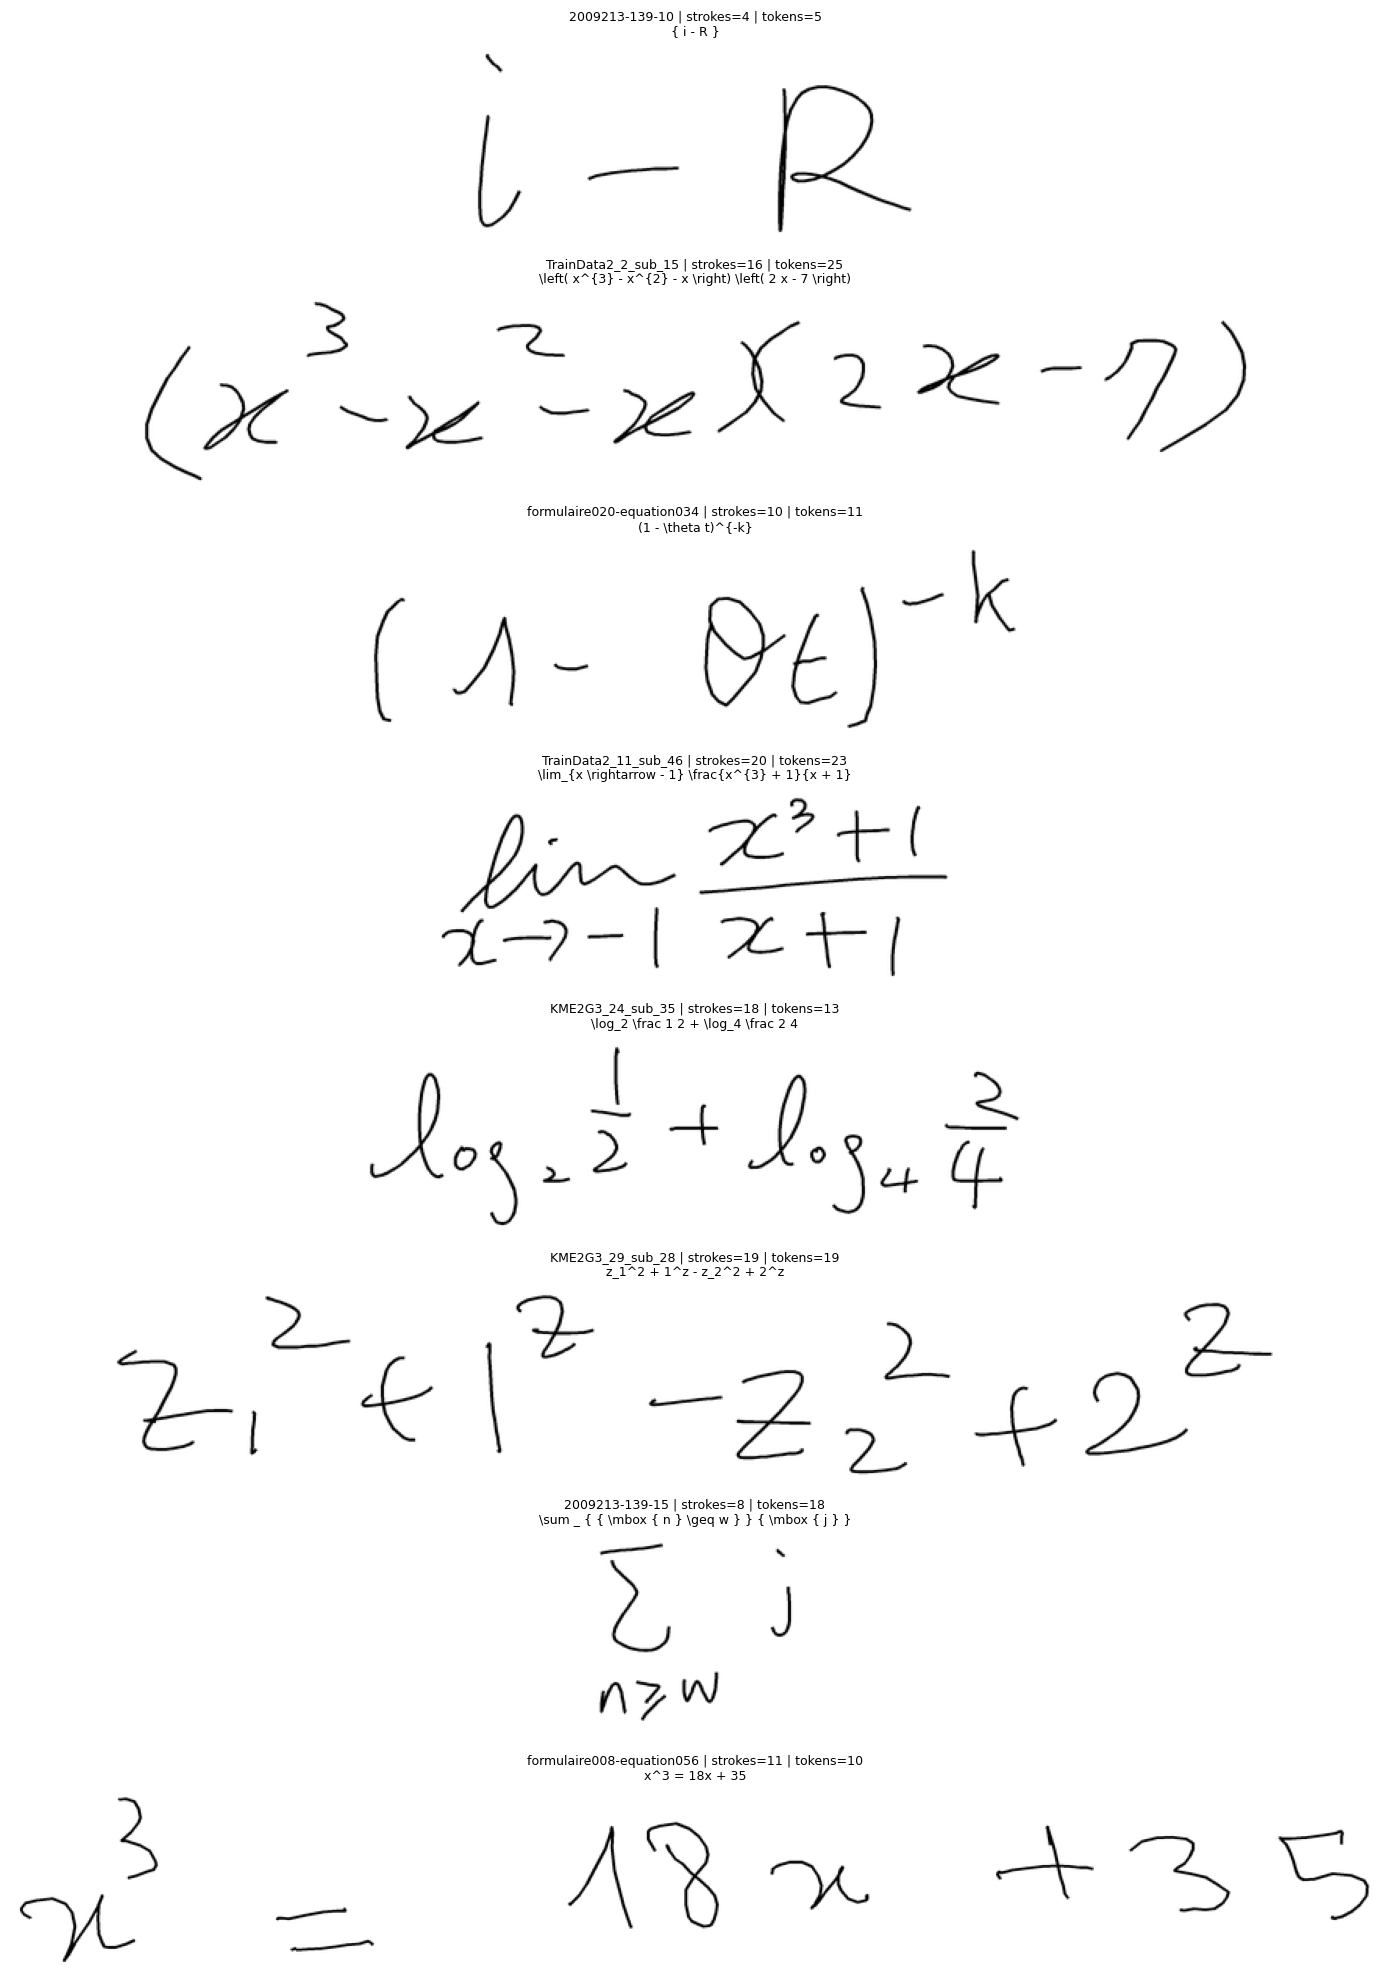

In [17]:
def show_samples(records, n=8, seed=42):
    rng = np.random.default_rng(seed)

    n = min(n, len(records))
    indices = rng.choice(len(records), size=n, replace=False)

    fig, axes = plt.subplots(
        n,
        1,
        figsize=(14, max(3, 2.5 * n)),
    )

    if n == 1:
        axes = [axes]

    for ax, index in zip(axes, indices):
        record = records[int(index)]
        image_path = PROCESSED_ROOT / record["image"]

        image = Image.open(image_path).convert("L")

        ax.imshow(image, cmap="gray")
        ax.axis("off")

        ax.set_title(
            f"{record['id']} | "
            f"strokes={record['num_strokes']} | "
            f"tokens={record['num_tokens']}\n"
            f"{record['latex']}",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


show_samples(train_records, n=8)


## 14. Inspect the longest target sequences

The exploration notebook identified very long CROHME expressions. These are especially important because the decoder must support long output sequences.


In [18]:
longest = (
    pd.DataFrame(train_records)
    .sort_values("sequence_length", ascending=False)
    [[
        "id",
        "file",
        "sequence_length",
        "num_strokes",
        "num_points",
        "image_width",
        "latex",
    ]]
    .head(10)
)

longest


,id,file,sequence_length,num_strokes,num_points,image_width,latex
8882,stat13,stat13.inkml,131,99,2829,1024,\log x(t) = \sum_{k=1}^{\infty} \frac{a_{k}}{k...
6904,formulaire009-equation014,formulaire009-equation014.inkml,90,55,1353,1017,p = \frac{{v_{0}}^{2} \sin(2\alpha)}{2a} + \sq...
8398,formulaire032-equation014,formulaire032-equation014.inkml,86,64,1481,1024,\frac{\pi^2}{8} = \frac{1}{1^2} + \frac{1}{3^2...
5214,MfrDB2991,MfrDB2991.inkml,83,44,1640,617,\sum_{n = 1}^{\infty} {( \frac{\sum_{i = 1}^{n...
5304,MfrDB3103,MfrDB3103.inkml,83,47,1409,446,\sum_{n = 1}^{\infty} {( \frac{\sum_{i = 1}^{n...
5257,MfrDB3044,MfrDB3044.inkml,83,49,2845,389,\sum_{n = 1}^{\infty} {( \frac{\sum_{i = 1}^{n...
5225,MfrDB3005,MfrDB3005.inkml,83,44,1359,412,\sum_{n = 1}^{\infty} {( \frac{\sum_{i = 1}^{n...
5348,MfrDB3158,MfrDB3158.inkml,83,46,1427,502,\sum_{n = 1}^{\infty} {( \frac{\sum_{i = 1}^{n...
5385,MfrDB3204,MfrDB3204.inkml,83,46,2119,395,\sum_{n = 1}^{\infty} {( \frac{\sum_{i = 1}^{n...
5349,MfrDB3160,MfrDB3160.inkml,83,39,1441,370,\sum_{n = 1}^{\infty} {( \frac{\sum_{i = 1}^{n...


## 15. Final preprocessing summary


In [19]:
print("=" * 70)
print("CROHME PREPROCESSING COMPLETE")
print("=" * 70)

print(f"Project root:       {PROJECT_ROOT}")
print(f"Dataset root:       {DATASET_ROOT}")
print(f"Processed root:     {PROCESSED_ROOT}")
print()

print(f"Train samples:      {len(train_records)}")
print(f"Valid samples:      {len(valid_records)}")
print(f"Test samples:       {len(test_records)}")
print(f"Failed files:       {len(all_failures)}")
print(f"Vocabulary size:    {len(vocab)}")
print()

print("Output directories:")
print(f"  Images:            {IMAGE_DIR}")
print(f"  Manifests:         {MANIFEST_DIR}")
print(f"  Metadata:          {METADATA_DIR}")
print()

print("Important files:")
print(f"  train.jsonl:       {train_manifest_path}")
print(f"  valid.jsonl:       {valid_manifest_path}")
print(f"  test.jsonl:        {test_manifest_path}")
print(f"  vocab.json:        {vocab_path}")
print(f"  failures:          {failures_path}")
print(f"  statistics:        {stats_path}")
print()

if validation_errors:
    print("STATUS: PREPROCESSING COMPLETED WITH VALIDATION ERRORS")
else:
    print("STATUS: PREPROCESSING AND VALIDATION PASSED")


CROHME PREPROCESSING COMPLETE
Project root:       /data1/students/abhista/HMER
Dataset root:       /data1/students/abhista/HMER/data/crohme2019
Processed root:     /data1/students/abhista/HMER/data/processed/crohme2019

Train samples:      8886
Valid samples:      972
Test samples:       1199
Failed files:       29
Vocabulary size:    121

Output directories:
  Images:            /data1/students/abhista/HMER/data/processed/crohme2019/images
  Manifests:         /data1/students/abhista/HMER/data/processed/crohme2019/manifests
  Metadata:          /data1/students/abhista/HMER/data/processed/crohme2019/metadata

Important files:
  train.jsonl:       /data1/students/abhista/HMER/data/processed/crohme2019/manifests/train.jsonl
  valid.jsonl:       /data1/students/abhista/HMER/data/processed/crohme2019/manifests/valid.jsonl
  test.jsonl:        /data1/students/abhista/HMER/data/processed/crohme2019/manifests/test.jsonl
  vocab.json:        /data1/students/abhista/HMER/data/processed/crohme20